# Synthetic Agent Value Profile Analysis

Validates the ValueBench regression pipeline by constructing synthetic agents with known
value priority weights and verifying that the pipeline recovers them. Each synthetic agent
scores choices via a weighted sum of value alignments, makes stochastic decisions through
a sigmoid probability model, and then has its value profile recovered — via logistic
regression followed by softmax(β / T) normalization — using the same pipeline applied to
real LLM/human decision-makers.

In [31]:
DIR = "/Users/payalchandak/Desktop/HVP Preprint/ValueBench"
import os
os.chdir(DIR)

import numpy as np
import pandas as pd
from scipy.special import expit
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import load_all_decisions, softmax_profile
from src.analysis.metrics import _get_alignment
from src.analysis.tradeoffs import _fit_logistic_regression
from src.response_models.case import VALUE_NAMES

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "sans-serif"

SEED = 42
rng = np.random.default_rng(SEED)

decisions = load_all_decisions()
print(f"Loaded {len(decisions)} decision records ({len(VALUE_NAMES)} values: {VALUE_NAMES})")

Loaded 51 decision records (4 values: ['autonomy', 'beneficence', 'nonmaleficence', 'justice'])


In [32]:
def compute_synthetic_profile(decisions, weights, n_runs=100, seed=42, temperature=1.0):
    """Simulate a synthetic agent with known value weights and recover its profile.

    For each case the agent scores both choices via a weighted sum of value
    alignments, converts the score difference to P(choice_1) through a sigmoid,
    then draws stochastic runs from a Binomial distribution.  The resulting
    simulated data is fed through the same logistic-regression pipeline used
    for real decision-makers so we can verify that the original weights are
    recoverable.

    Args:
        decisions: List of DecisionRecord objects (only ``record.case`` is used).
        weights: Dict mapping each value name to a priority weight,
            e.g. ``{"autonomy": 0.7, "beneficence": 0.1, ...}``.
        n_runs: Number of simulated Binomial trials per case.
        seed: Random seed for reproducibility.
        temperature: Softmax temperature *T* forwarded to
            :func:`softmax_profile`.  Default ``1.0`` (standard softmax).

    Returns:
        ``(coefficients, profile)`` where *coefficients* is a dict of
        recovered β values and *profile* is the softmax-normalized
        probability distribution over values.
    """
    sim_rng = np.random.default_rng(seed)
    w = np.array([weights[v] for v in VALUE_NAMES], dtype=np.float64)

    X_rows = []
    y_values = []
    n_trials_values = []

    for record in decisions:
        delta = np.array([
            _get_alignment(record.case.choice_1, v)
            - _get_alignment(record.case.choice_2, v)
            for v in VALUE_NAMES
        ], dtype=np.float64)

        score_diff = float(w @ delta)
        p_c1 = float(expit(score_diff))

        c1_count = int(sim_rng.binomial(n_runs, p_c1))

        X_rows.append(delta)
        y_values.append(c1_count / n_runs)
        n_trials_values.append(n_runs)

    X = np.array(X_rows, dtype=np.float64)
    y = np.array(y_values, dtype=np.float64)
    n_trials = np.array(n_trials_values, dtype=np.intp)

    coefficients, _, _, _ = _fit_logistic_regression(X, y, n_trials)
    profile = softmax_profile(coefficients, temperature=temperature)

    return coefficients, profile

In [33]:
PRIORITY_WEIGHT = 0.97
BACKGROUND_WEIGHT = 0.01

SYNTHETIC_AGENTS = {
    name: {v: PRIORITY_WEIGHT if v == name else BACKGROUND_WEIGHT for v in VALUE_NAMES}
    for name in VALUE_NAMES
}

for agent_name, weights in SYNTHETIC_AGENTS.items():
    print(f"{agent_name:>16}: {weights}")

        autonomy: {'autonomy': 0.97, 'beneficence': 0.01, 'nonmaleficence': 0.01, 'justice': 0.01}
     beneficence: {'autonomy': 0.01, 'beneficence': 0.97, 'nonmaleficence': 0.01, 'justice': 0.01}
  nonmaleficence: {'autonomy': 0.01, 'beneficence': 0.01, 'nonmaleficence': 0.97, 'justice': 0.01}
         justice: {'autonomy': 0.01, 'beneficence': 0.01, 'nonmaleficence': 0.01, 'justice': 0.97}


In [34]:
TEMPERATURE = 0.25

rows = []
all_coefficients = {}

for agent_name, weights in SYNTHETIC_AGENTS.items():
    coefficients, profile = compute_synthetic_profile(decisions, weights, n_runs=100, seed=SEED, temperature=TEMPERATURE)
    all_coefficients[agent_name] = coefficients
    for value_name, prob in profile.items():
        rows.append({
            "agent": agent_name.capitalize(),
            "value": value_name.capitalize(),
            "profile_weight": prob,
            "ground_truth": weights[value_name],
        })

results_df = pd.DataFrame(rows)
results_df

,agent,value,profile_weight,ground_truth
0,Autonomy,Autonomy,0.938790,0.97
1,Autonomy,Beneficence,0.022004,0.01
2,Autonomy,Nonmaleficence,0.020372,0.01
3,Autonomy,Justice,0.018834,0.01
4,Beneficence,Autonomy,0.019106,0.01
5,Beneficence,Beneficence,0.944769,0.97
6,Beneficence,Nonmaleficence,0.017414,0.01
7,Beneficence,Justice,0.018711,0.01
8,Nonmaleficence,Autonomy,0.020499,0.01
9,Nonmaleficence,Beneficence,0.018420,0.01


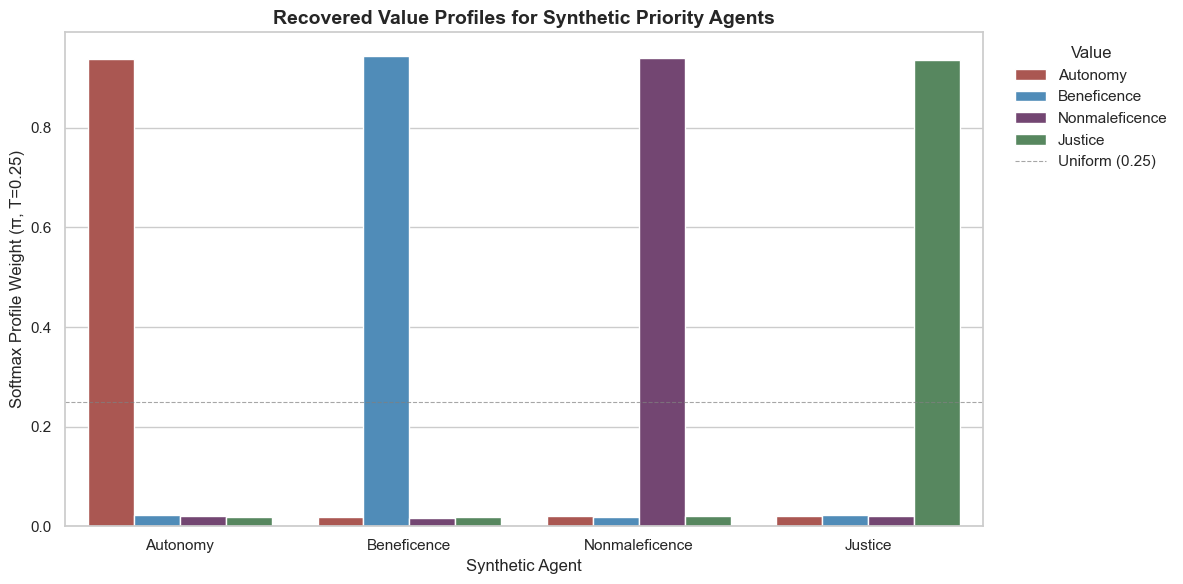

In [35]:
agent_colors = {
    "Autonomy": "#B84A44",
    "Beneficence": "#3F8FC9",
    "Nonmaleficence": "#7A3E7A",
    "Justice": "#4F8F5A",
}

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="agent",
    y="profile_weight",
    hue="value",
    palette=[agent_colors.get(v, "#888888") for v in results_df["value"].unique()],
    ax=ax,
)

ax.axhline(y=0.25, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="Uniform (0.25)")
ax.set_xlabel("Synthetic Agent", fontsize=12)
ax.set_ylabel(f"Softmax Profile Weight (π, T={TEMPERATURE})", fontsize=12)
ax.set_title("Recovered Value Profiles for Synthetic Priority Agents", fontsize=14, fontweight="bold")
ax.legend(title="Value", loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
plt.tight_layout()
plt.show()